# Early Fusion Analysis

**Strategy**: Concatenate vectors TRƯỚC KHI classify

```
BERT embedding + TF-IDF embedding → Concatenate → Single LogReg → Prediction
```

**Pros**: Single classifier learns joint representation  
**Cons**: High dimensionality, curse of dimensionality risk

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## 1. Load Embeddings

In [2]:
ENCODED_DIR = PROJECT_ROOT / 'data' / 'encoded'

df = pd.read_csv(ENCODED_DIR / 'final_data_shuffled.csv')
labels = df['label'].values
print(f"Samples: {len(labels)}, Distribution: {dict(pd.Series(labels).value_counts())}")

Samples: 4736, Distribution: {0: 3929, 1: 807}


In [3]:
# Load BERT embeddings
embeddings = {}

bert_configs = [
    ('phobertv2', 'pretrained', 'PhoBERT-v2-Pretrained'),
    ('phobertv2', 'finetuned', 'PhoBERT-v2-Finetuned'),
    ('visobert', 'pretrained', 'ViSoBERT-Pretrained'),
    ('visobert', 'finetuned', 'ViSoBERT-Finetuned'),
    ('phobertlarge', 'pretrained', 'PhoBERT-Large-Pretrained'),
    ('phobertlarge', 'finetuned', 'PhoBERT-Large-Finetuned'),
]

for folder, suffix, name in bert_configs:
    path = ENCODED_DIR / folder / f'{suffix}_embeddings.npy'
    if path.exists():
        embeddings[name] = np.load(path)
        print(f"✓ {name}: {embeddings[name].shape}")

# Load TF-IDF
tfidf_emb = np.load(ENCODED_DIR / 'tfidf' / 'tfidf_embeddings.npy')
print(f"✓ TF-IDF: {tfidf_emb.shape}")

✓ PhoBERT-v2-Pretrained: (4736, 88)
✓ PhoBERT-v2-Finetuned: (4736, 68)
✓ ViSoBERT-Pretrained: (4736, 178)
✓ ViSoBERT-Finetuned: (4736, 68)
✓ PhoBERT-Large-Pretrained: (4736, 144)
✓ PhoBERT-Large-Finetuned: (4736, 24)
✓ TF-IDF: (4736, 120)


## 2. Evaluation Setup

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

def evaluate_embedding(X, y, name=""):
    """10-Fold CV evaluation"""
    X_scaled = StandardScaler().fit_transform(X)
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    auc = cross_val_score(clf, X_scaled, y, cv=cv, scoring='roc_auc')
    f1 = cross_val_score(clf, X_scaled, y, cv=cv, scoring='f1')
    prec = cross_val_score(clf, X_scaled, y, cv=cv, scoring='precision')
    rec = cross_val_score(clf, X_scaled, y, cv=cv, scoring='recall')
    
    return {
        'name': name, 'dim': X.shape[1],
        'auc_mean': auc.mean(), 'auc_std': auc.std(),
        'f1_mean': f1.mean(), 'f1_std': f1.std(),
        'prec_mean': prec.mean(), 'prec_std': prec.std(),
        'rec_mean': rec.mean(), 'rec_std': rec.std()
    }

## 3. Evaluate Individual Baselines

In [5]:
print("Evaluating individual embeddings (baselines)...\n")

individual_results = []
for name, emb in tqdm(embeddings.items(), desc="Individual"):
    r = evaluate_embedding(emb, labels, name)
    individual_results.append(r)
    print(f"{name:<30}: AUC={r['auc_mean']:.4f}")

# TF-IDF baseline
tfidf_result = evaluate_embedding(tfidf_emb, labels, 'TF-IDF')
individual_results.append(tfidf_result)
print(f"{'TF-IDF':<30}: AUC={tfidf_result['auc_mean']:.4f}")

df_individual = pd.DataFrame(individual_results)

Evaluating individual embeddings (baselines)...



Individual:  17%|█▋        | 1/6 [00:00<00:02,  2.30it/s]

PhoBERT-v2-Pretrained         : AUC=0.9314


Individual:  33%|███▎      | 2/6 [00:00<00:01,  2.18it/s]

PhoBERT-v2-Finetuned          : AUC=0.9770


...

Individual:  83%|████████▎ | 5/6 [00:02<00:00,  1.83it/s]

PhoBERT-Large-Pretrained      : AUC=0.8998


Individual: 100%|██████████| 6/6 [00:02<00:00,  2.01it/s]

PhoBERT-Large-Finetuned       : AUC=0.9832


TF-IDF                        : AUC=0.8756


## 4. Early Fusion: BERT + TF-IDF Concatenation

In [6]:
print("\nEvaluating Early Fusion (BERT + TF-IDF concatenated)...\n")

early_fusion_results = []

for bert_name, bert_emb in tqdm(embeddings.items(), desc="Early Fusion"):
    # Concatenate BERT + TF-IDF
    fused_emb = np.hstack([bert_emb, tfidf_emb])
    fusion_name = f"{bert_name} + TF-IDF"
    
    r = evaluate_embedding(fused_emb, labels, fusion_name)
    
    # Store additional info for comparison
    bert_auc = df_individual[df_individual['name'] == bert_name]['auc_mean'].values[0]
    r['bert_only_auc'] = bert_auc
    r['improvement'] = (r['auc_mean'] - bert_auc) * 100
    
    early_fusion_results.append(r)
    print(f"{fusion_name:<45}: dim={r['dim']:>5}, AUC={r['auc_mean']:.4f} ({r['improvement']:+.2f}%)")

df_early_fusion = pd.DataFrame(early_fusion_results)


Evaluating Early Fusion (BERT + TF-IDF concatenated)...



Early Fusion:  17%|█▋        | 1/6 [00:01<00:05,  1.06s/it]

PhoBERT-v2-Pretrained + TF-IDF               : dim=  208, AUC=0.9315 (+0.01%)


Early Fusion:  33%|███▎      | 2/6 [00:02<00:04,  1.00s/it]

PhoBERT-v2-Finetuned + TF-IDF                : dim=  188, AUC=0.9722 (-0.48%)


...

ViSoBERT-Finetuned + TF-IDF                  : dim=  188, AUC=0.9611 (-0.53%)


Early Fusion:  83%|████████▎ | 5/6 [00:05<00:01,  1.10s/it]

PhoBERT-Large-Pretrained + TF-IDF            : dim=  264, AUC=0.9145 (+1.46%)


Early Fusion: 100%|██████████| 6/6 [00:06<00:00,  1.07s/it]

PhoBERT-Large-Finetuned + TF-IDF             : dim=  144, AUC=0.9803 (-0.29%)


In [7]:
# Results Table
print("\n" + "="*110)
print("EARLY FUSION RESULTS (10-Fold CV)")
print("="*110)
print(f"{'Model':<45} {'Dim':>6} {'AUC':>14} {'F1':>14} {'BERT Only':>10} {'Change':>10}")
print("-"*110)

for _, row in df_early_fusion.iterrows():
    change_str = f"{row['improvement']:+.2f}%"
    print(f"{row['name']:<45} {row['dim']:>6} "
          f"{row['auc_mean']:.4f}±{row['auc_std']:.3f}  "
          f"{row['f1_mean']:.4f}±{row['f1_std']:.3f}  "
          f"{row['bert_only_auc']:.4f}    "
          f"{change_str:>10}")
print("="*110)


EARLY FUSION RESULTS (10-Fold CV)
Model                                            Dim            AUC             F1  BERT Only     Change
--------------------------------------------------------------------------------------------------------------
PhoBERT-v2-Pretrained + TF-IDF                   208 0.9315±0.013  0.6757±0.032  0.9314        +0.01%
PhoBERT-v2-Finetuned + TF-IDF                    188 0.9722±0.010  0.8331±0.018  0.9770        -0.48%
ViSoBERT-Pretrained + TF-IDF                     298 0.8882±0.014  0.5942±0.023  0.8728        +1.54%
ViSoBERT-Finetuned + TF-IDF                      188 0.9611±0.013  0.7892±0.016  0.9665        -0.53%
PhoBERT-Large-Pretrained + TF-IDF                264 0.9145±0.015  0.6541±0.025  0.8998        +1.46%
PhoBERT-Large-Finetuned + TF-IDF                 144 0.9803±0.011  0.8769±0.027  0.9832        -0.29%


## 5. Dimension Analysis

In [8]:
print("\n" + "="*80)
print("DIMENSION ANALYSIS")
print("="*80)

tfidf_dim = tfidf_emb.shape[1]
print(f"TF-IDF dimension: {tfidf_dim}")
print()

for name, emb in embeddings.items():
    bert_dim = emb.shape[1]
    combined_dim = bert_dim + tfidf_dim
    ratio = tfidf_dim / bert_dim
    print(f"{name}: {bert_dim} + {tfidf_dim} = {combined_dim} (TF-IDF is {ratio:.1f}x BERT)")

print("\n" + "-"*80)
print("WHY EARLY FUSION MAY DECREASE PERFORMANCE:")
print("-"*80)
print("1. Curse of dimensionality: Too many features for sample size")
print("2. TF-IDF dominates: TF-IDF dim >> BERT dim")
print("3. Feature redundancy: Both capture similar patterns")
print("4. For Finetuned BERT: Already task-specific, TF-IDF adds noise")
print("="*80)


DIMENSION ANALYSIS
TF-IDF dimension: 120

PhoBERT-v2-Pretrained: 88 + 120 = 208 (TF-IDF is 1.4x BERT)
PhoBERT-v2-Finetuned: 68 + 120 = 188 (TF-IDF is 1.8x BERT)
ViSoBERT-Pretrained: 178 + 120 = 298 (TF-IDF is 0.7x BERT)
ViSoBERT-Finetuned: 68 + 120 = 188 (TF-IDF is 1.8x BERT)
PhoBERT-Large-Pretrained: 144 + 120 = 264 (TF-IDF is 0.8x BERT)
PhoBERT-Large-Finetuned: 24 + 120 = 144 (TF-IDF is 5.0x BERT)

--------------------------------------------------------------------------------
WHY EARLY FUSION MAY DECREASE PERFORMANCE:
--------------------------------------------------------------------------------
1. Curse of dimensionality: Too many features for sample size
2. TF-IDF dominates: TF-IDF dim >> BERT dim
3. Feature redundancy: Both capture similar patterns
4. For Finetuned BERT: Already task-specific, TF-IDF adds noise


## 6. Visualization

In [9]:
# Define order for plots
correct_order = [
    'PhoBERT-v2-Pretrained', 'PhoBERT-v2-Finetuned',
    'ViSoBERT-Pretrained', 'ViSoBERT-Finetuned',
    'PhoBERT-Large-Pretrained', 'PhoBERT-Large-Finetuned'
]

x_labels = ['PhoBERT-v2\nPretrained', 'PhoBERT-v2\nFinetuned',
            'ViSoBERT\nPretrained', 'ViSoBERT\nFinetuned',
            'PhoBERT-Large\nPretrained', 'PhoBERT-Large\nFinetuned']

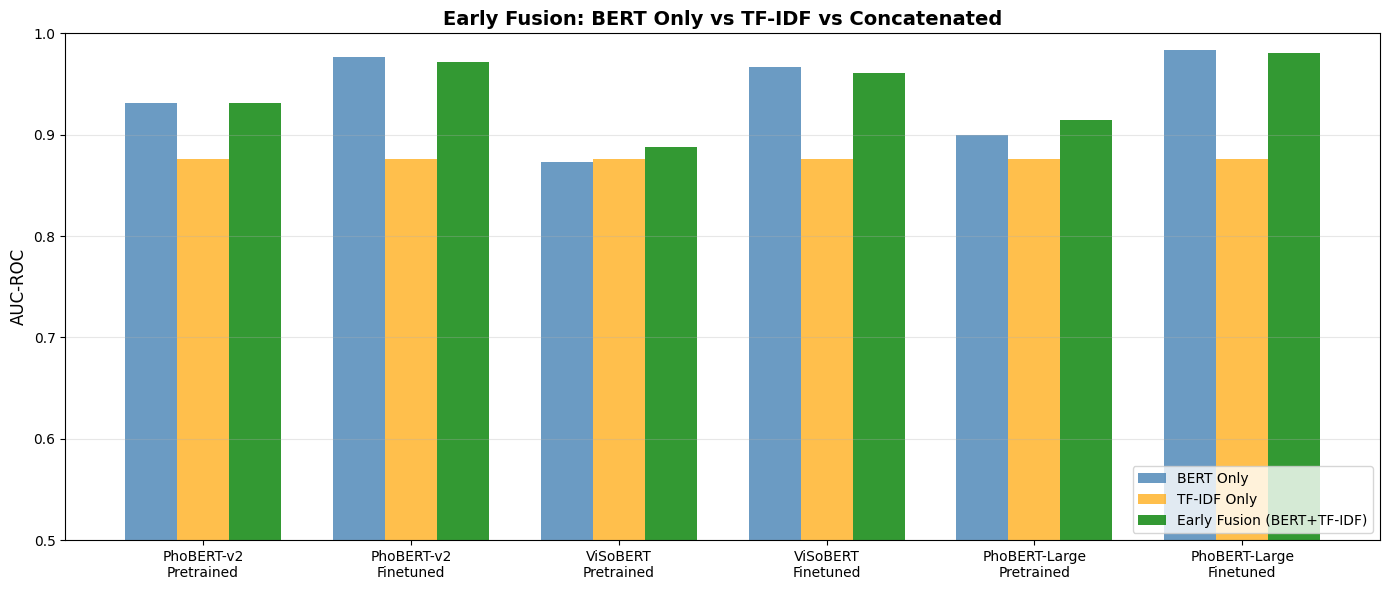

In [10]:
# Plot 1: BERT vs TF-IDF vs Early Fusion
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(correct_order))
width = 0.25

# Get values in correct order
bert_auc = [df_individual[df_individual['name'] == n]['auc_mean'].values[0] for n in correct_order]
tfidf_auc = df_individual[df_individual['name'] == 'TF-IDF']['auc_mean'].values[0]
fusion_auc = [df_early_fusion[df_early_fusion['name'] == f"{n} + TF-IDF"]['auc_mean'].values[0] for n in correct_order]

bars1 = ax.bar(x - width, bert_auc, width, label='BERT Only', color='steelblue', alpha=0.8)
bars2 = ax.bar(x, [tfidf_auc]*len(x), width, label='TF-IDF Only', color='orange', alpha=0.7)
bars3 = ax.bar(x + width, fusion_auc, width, label='Early Fusion (BERT+TF-IDF)', color='green', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Early Fusion: BERT Only vs TF-IDF vs Concatenated', fontweight='bold', fontsize=14)
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

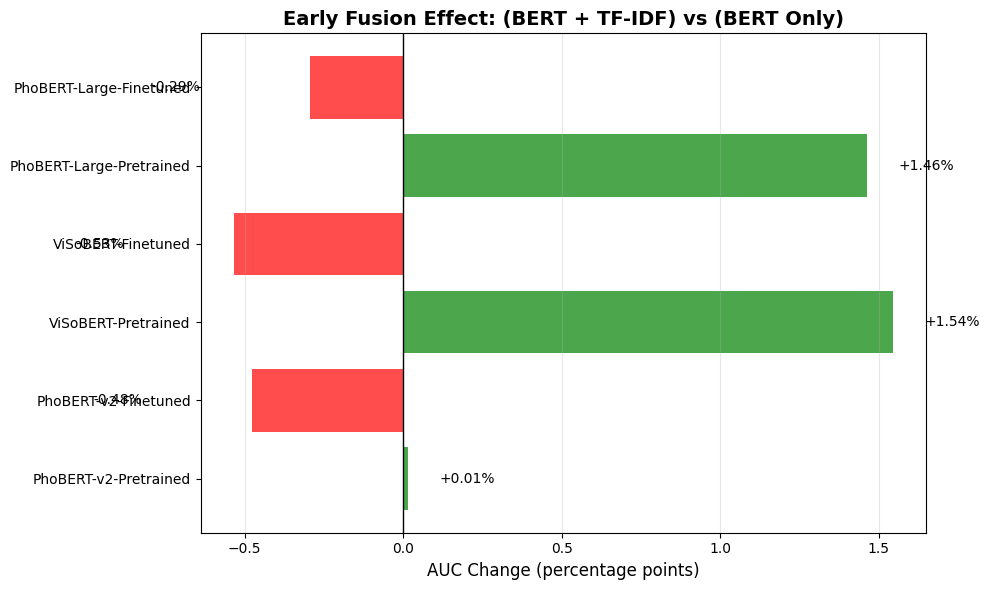

In [11]:
# Plot 2: AUC Improvement from Early Fusion
fig, ax = plt.subplots(figsize=(10, 6))

improvements = [df_early_fusion[df_early_fusion['name'] == f"{n} + TF-IDF"]['improvement'].values[0] 
                for n in correct_order]
colors = ['green' if x > 0 else 'red' for x in improvements]

bars = ax.barh(correct_order, improvements, color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=1)

# Add value labels
for bar, imp in zip(bars, improvements):
    offset = 0.1 if imp >= 0 else -0.5
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
            f'{imp:+.2f}%', va='center', fontsize=10)

ax.set_xlabel('AUC Change (percentage points)', fontsize=12)
ax.set_title('Early Fusion Effect: (BERT + TF-IDF) vs (BERT Only)', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

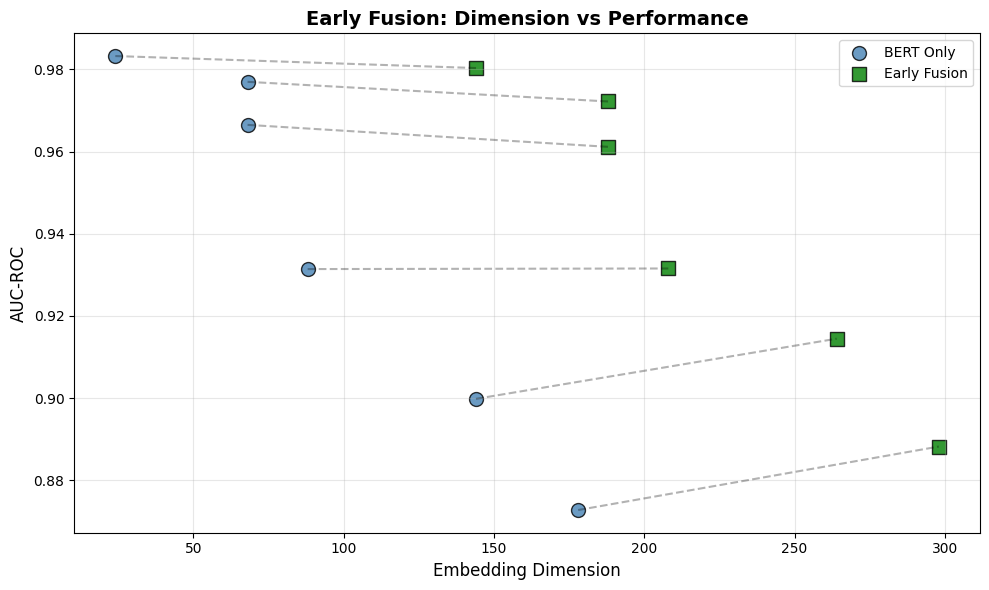

In [12]:
# Plot 3: Dimension vs Performance for Early Fusion
fig, ax = plt.subplots(figsize=(10, 6))

# BERT only points
df_bert_only = df_individual[df_individual['name'] != 'TF-IDF']
ax.scatter(df_bert_only['dim'], df_bert_only['auc_mean'], 
           s=100, c='steelblue', label='BERT Only', alpha=0.8, edgecolors='black')

# Early Fusion points
ax.scatter(df_early_fusion['dim'], df_early_fusion['auc_mean'], 
           s=100, c='green', marker='s', label='Early Fusion', alpha=0.8, edgecolors='black')

# Connect corresponding points with lines
for bert_name in correct_order:
    bert_row = df_individual[df_individual['name'] == bert_name].iloc[0]
    fusion_row = df_early_fusion[df_early_fusion['name'] == f"{bert_name} + TF-IDF"].iloc[0]
    ax.plot([bert_row['dim'], fusion_row['dim']], 
            [bert_row['auc_mean'], fusion_row['auc_mean']], 
            'k--', alpha=0.3)

ax.set_xlabel('Embedding Dimension', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Early Fusion: Dimension vs Performance', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

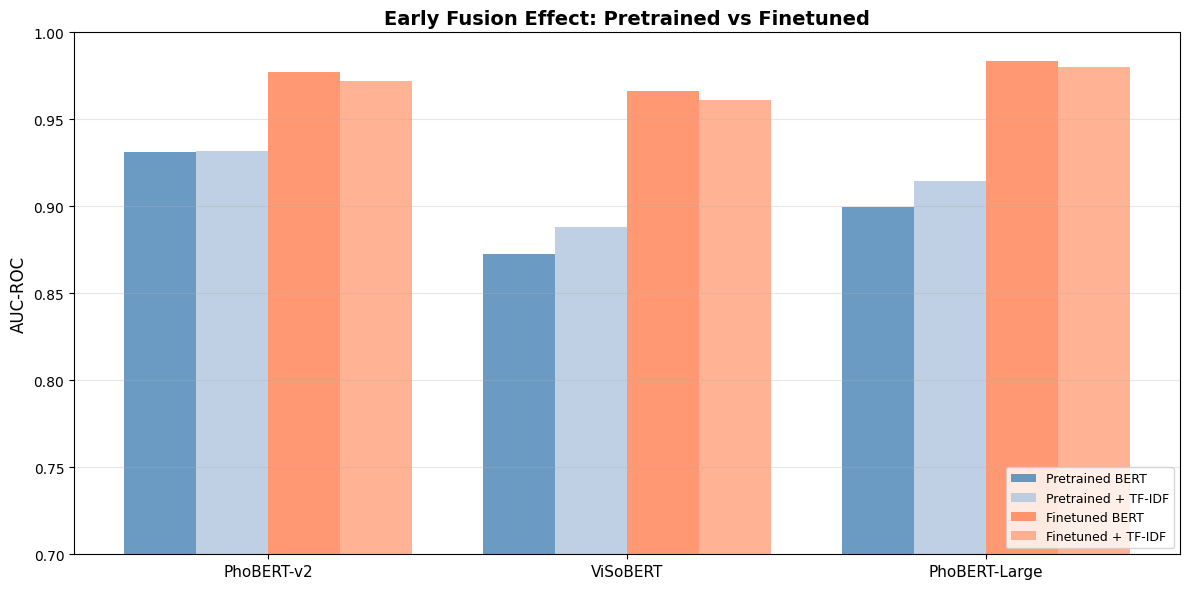

In [13]:
# Plot 4: Pretrained vs Finetuned - Early Fusion Effect
fig, ax = plt.subplots(figsize=(12, 6))

bert_models = ['PhoBERT-v2', 'ViSoBERT', 'PhoBERT-Large']
x = np.arange(len(bert_models))
width = 0.2

# Get values for each category
pre_bert = [df_individual[df_individual['name'] == f"{m}-Pretrained"]['auc_mean'].values[0] for m in bert_models]
pre_fusion = [df_early_fusion[df_early_fusion['name'] == f"{m}-Pretrained + TF-IDF"]['auc_mean'].values[0] for m in bert_models]
fine_bert = [df_individual[df_individual['name'] == f"{m}-Finetuned"]['auc_mean'].values[0] for m in bert_models]
fine_fusion = [df_early_fusion[df_early_fusion['name'] == f"{m}-Finetuned + TF-IDF"]['auc_mean'].values[0] for m in bert_models]

ax.bar(x - 1.5*width, pre_bert, width, label='Pretrained BERT', color='steelblue', alpha=0.8)
ax.bar(x - 0.5*width, pre_fusion, width, label='Pretrained + TF-IDF', color='lightsteelblue', alpha=0.8)
ax.bar(x + 0.5*width, fine_bert, width, label='Finetuned BERT', color='coral', alpha=0.8)
ax.bar(x + 1.5*width, fine_fusion, width, label='Finetuned + TF-IDF', color='lightsalmon', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(bert_models, fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Early Fusion Effect: Pretrained vs Finetuned', fontweight='bold', fontsize=14)
ax.set_ylim(0.7, 1.0)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Summary

In [14]:
print("\n" + "="*70)
print("EARLY FUSION ANALYSIS - SUMMARY")
print("="*70)

# Best models
best_bert_only = df_individual[df_individual['name'] != 'TF-IDF'].loc[
    df_individual[df_individual['name'] != 'TF-IDF']['auc_mean'].idxmax()
]
best_early_fusion = df_early_fusion.loc[df_early_fusion['auc_mean'].idxmax()]

print(f"\n[BEST BERT ONLY]")
print(f"  Model: {best_bert_only['name']}")
print(f"  AUC:   {best_bert_only['auc_mean']:.4f} ± {best_bert_only['auc_std']:.4f}")
print(f"  Dim:   {best_bert_only['dim']}")

print(f"\n[BEST EARLY FUSION]")
print(f"  Model: {best_early_fusion['name']}")
print(f"  AUC:   {best_early_fusion['auc_mean']:.4f} ± {best_early_fusion['auc_std']:.4f}")
print(f"  Dim:   {best_early_fusion['dim']}")
print(f"  vs BERT only: {best_early_fusion['improvement']:+.2f}%")

# Count improvements
improved = (df_early_fusion['improvement'] > 0).sum()
decreased = (df_early_fusion['improvement'] < 0).sum()

print(f"\n[EARLY FUSION EFFECT]")
print(f"  Improved:  {improved}/{len(df_early_fusion)} models")
print(f"  Decreased: {decreased}/{len(df_early_fusion)} models")

avg_pre_change = df_early_fusion[df_early_fusion['name'].str.contains('Pretrained')]['improvement'].mean()
avg_fine_change = df_early_fusion[df_early_fusion['name'].str.contains('Finetuned')]['improvement'].mean()

print(f"\n  Avg change (Pretrained): {avg_pre_change:+.2f}%")
print(f"  Avg change (Finetuned):  {avg_fine_change:+.2f}%")

print("\n" + "-"*70)
print("KEY FINDINGS:")
print("-"*70)
print("1. Early Fusion tends to DECREASE performance for Finetuned models")
print("2. Early Fusion may slightly help Pretrained models")
print("3. Concatenation creates high-dimensional space (curse of dimensionality)")
print("4. TF-IDF dimension >> BERT dimension, may dominate classifier")
print("="*70)


EARLY FUSION ANALYSIS - SUMMARY

[BEST BERT ONLY]
  Model: PhoBERT-Large-Finetuned
  AUC:   0.9832 ± 0.0127
  Dim:   24

[BEST EARLY FUSION]
  Model: PhoBERT-Large-Finetuned + TF-IDF
  AUC:   0.9803 ± 0.0109
  Dim:   144
  vs BERT only: -0.29%

[EARLY FUSION EFFECT]
  Improved:  3/6 models
  Decreased: 3/6 models

  Avg change (Pretrained): +1.01%
  Avg change (Finetuned):  -0.43%

----------------------------------------------------------------------
KEY FINDINGS:
----------------------------------------------------------------------
1. Early Fusion tends to DECREASE performance for Finetuned models
2. Early Fusion may slightly help Pretrained models
3. Concatenation creates high-dimensional space (curse of dimensionality)
4. TF-IDF dimension >> BERT dimension, may dominate classifier
